# PSF Construction

This notebook presents the construction of a PSF model from HST/ACS F555W imaging. The PSF is later used for aperture photometry and GALFIT PSF subtraction to investigate possible foreground sources and lensing signatures.

* Section 1: Extraction of AB magnitude, zero point, background image, center and cut original image for analysis.
* Section 2: Selection of stars for PSF construction.
* Section 3: PSF construction.



In [1]:
#Import libraries
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.utils.data import download_file
from astropy.wcs import WCS
from photutils.centroids import centroid_2dg, centroid_sources
from photutils.aperture import CircularAperture
from photutils.aperture import CircularAnnulus
from photutils.aperture import aperture_photometry
from photutils.aperture import ApertureStats
import numpy as np
import matplotlib.pyplot as plt

## Section 1: GALFIT image creation
In this section we center and cut the image around our target position for GALFIT. We calculate AB magnitude, background, and create and error image for the usage of GALFIT. 

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     815   ()      
  1  SCI           1 ImageHDU        81   (4218, 4245)   float32   
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 170.7993279036776 20.18751957092904 
CRPIX : 2109.0 2122.5 
CD1_1 CD1_2  : 2.67477941446969e-06 1.36288953936784e-05 
CD2_1 CD2_2  : 1.36288953936784e-05 -2.6747794144696e-06 
NAXIS : 4218  4245

AB ZERO Point
25.699605770884762

The average background is 0.232164307049049
The median background is 0.08634796738624573
The std of the background is 7.30614325116703

Target AB-magnitude
24.17622589742729


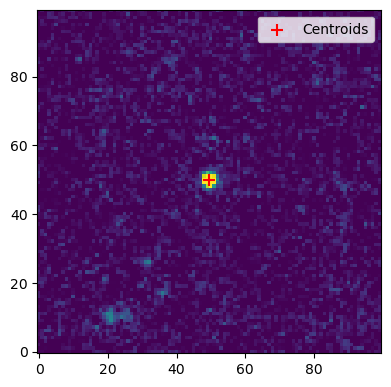

In [3]:
# Making a cutout of 100x100 considering to transform the data in counts [ADU]
x_qso, y_qso = 4006.2284, 4042.1703 # The quasar location is roughly 4007.2284 and 4007.2284 (in ds9).
size = 100

# Load the data image and the WCS (World Coordinate System) to identidy position in sky
hdul = fits.open('jf3j02010_drz.fits').copy() 
# removing not used extensions in fits file
del hdul[4]
del hdul[3]
del hdul[2]
hdul.info()
wcs = WCS(hdul[1].header) 
print(wcs)
#Define the data, center the image in the previous points
position = centroid_sources(hdul[1].data, x_qso, y_qso, box_size=21,
                        centroid_func=centroid_2dg)


# Make the cutout, including the WCS
cutout = Cutout2D(hdul[1].data, position=position, size=size, wcs=wcs)

# Put the cutout image in the FITS HDU
hdul[1].data = cutout.data

# Update the FITS header with the cutout WCS
hdul[1].header.update(cutout.wcs.to_header())
hdul[0].header.update(cutout.wcs.to_header())

# Data are in e-/counts but for GALFIT (software later used for analysis) wants ADU
# CCDGAIN =                  2.0 / commanded gain of CCD                          
# ATODGNA =        2.0200000E+00 / calibrated gain for amplifier A                
# ATODGNB =        1.8860000E+00 / calibrated gain for amplifier B                
# ATODGNC =        2.0170000E+00 / calibrated gain for amplifier C                
# ATODGND =        2.0109999E+00 / calibrated gain for amplifier D                
# EXPTIME =               2080.0 / exposure duration (seconds)--calculated
hdul[1].data = hdul[1].data*hdul[0].header['EXPTIME'] # convert from e-/s to e-
hdul[1].header['EXPTIME'] = hdul[0].header['EXPTIME']
# EXPTIME already takes into account that we have 4 exposures (TEXPTIME=EXPITME)
# so to make things consistent, I changed NCOMBINE from 4 to 1.
hdul[1].header['NCOMBINE'] = 1
hdul[0].header['NCOMBINE'] = 1
# if the detector is aligned as I think, the QSO should be in amplifier B,
# which has a slightly lower gain and using this for converting from e- to ADU
hdul[0].header['GAIN'] = hdul[0].header['ATODGNB']
hdul[1].header['GAIN'] = hdul[0].header['ATODGNB']
hdul[1].data = hdul[1].data/hdul[0].header['GAIN'] # convert from e- to ADU
hdul[1].header['BUNIT']  = 'ADU'

# conversion of the ZERO Point
# PHOTZPT =       -2.1100000E+01 / ST magnitude zero point                        
# PHOTFLAM=        1.9882054E-19 / inverse sensitivity, ergs/cm2/Ang/electron     
# PHOTPLAM=        5.3610298E+03 / Pivot wavelength (Angstroms)                   
# ZPAB=−2.5∗log10(PHOTFLAM)−5∗log10(PHOTPLAM)−2.408
hdul[1].header['PHOTZPAB'] = -2.5*np.log10(hdul[1].header['PHOTFLAM']) -5.0*np.log10(hdul[1].header['PHOTPLAM']) -2.408
hdul[0].header['PHOTZPAB'] = -2.5*np.log10(hdul[1].header['PHOTFLAM']) -5.0*np.log10(hdul[1].header['PHOTPLAM']) -2.408
print('\nAB ZERO Point') #This will give us the zero point
print(hdul[1].header['PHOTZPAB']) 


#Size of the image in pixels
size = 100
x_ap, y_ap = size/2., size/2.
position_cent = centroid_sources(hdul[1].data, x_ap, y_ap, box_size=11,
                        centroid_func=centroid_2dg)
position_ap = float(position_cent[0][0]), float(position_cent[1][0])
#Aperture around the target position
aperture = CircularAperture(position_ap, r=10.0)
#Aperture for the background estimation
aperture_bg = CircularAnnulus(position_ap, r_in=12.0, r_out=30.0)
aperstats = ApertureStats(hdul[1].data, aperture_bg)
bkg_mean = aperstats.mean
bgk_median = aperstats.median
bgk_std = aperstats.std
print('\nThe average background is {}'.format(bkg_mean))
print('The median background is {}'.format(bgk_median))
print('The std of the background is {}'.format(bgk_std))
#Create photometry table
phot_table = aperture_photometry(hdul[1].data-bgk_median, aperture)
print('\nTarget AB-magnitude') #This magnitude is necessary as an aproximation for GALFIT input file
print(hdul[1].header['PHOTZPAB']-2.5*np.log10(phot_table['aperture_sum'][0]*hdul[1].header['GAIN']/hdul[1].header['EXPTIME']))

# Write the cutout to a new FITS file
cutout_filename = "P170+20_cutout.fits"
hdul.writeto(cutout_filename, overwrite=True, output_verify = 'fix')

#Plot image
plt.figure(figsize=(4, 4))
plt.imshow(hdul[1].data, origin='lower', interpolation='nearest', vmin=0, vmax=100)
plt.scatter(*position_cent, marker='+', s=80, color='red', label='Centroids')
plt.legend()
plt.tight_layout()

#making the error file:
hdul = fits.open(cutout_filename)
hdul_noise = hdul.copy()
hdul_noise[1].data[:,:] = bgk_std
hdul_noise[0].data = hdul_noise[1].data
del hdul_noise[1]
hdul_noise.writeto(cutout_filename.replace('.fits','_std.fits'), overwrite=True, output_verify = 'fix')
hdul.close()
hdul_noise.close()

#making simpler fits
hdul = fits.open(cutout_filename)
hdul_simple = hdul.copy()
hdul_simple[0].data = hdul_simple[1].data
del hdul_simple[1]
hdul_simple.writeto(cutout_filename.replace('.fits','_simple.fits'), overwrite=True, output_verify = 'fix')
hdul.close()
hdul_simple.close()

In [4]:
old = fits.open(cutout_filename)
old.info()
new = fits.open(cutout_filename.replace('.fits','_simple.fits'))
new.info()
old.close()
new.close()

Filename: P170+20_cutout.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     840   ()      
  1  SCI           1 ImageHDU        94   (100, 100)   float32   
Filename: P170+20_cutout_simple.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     842   (100, 100)   float32   


## Section 2: Selection of stars 
In this section we extract images using photutils library. In our image was not available enough stars for the construction of the PSF, therefore we found another image in the archive of HST with the same instrument and position.

Filename: /users/aurora.mata/Documents/PJ170+20/j8rz01020_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     787   ()      
  1  SCI           1 ImageHDU        82   (4218, 4240)   float32   
<TableColumns names=('id','xcentroid','ycentroid','sharpness','roundness1','roundness2','npix','peak','flux','mag','daofind_mag')>

Total stars 104


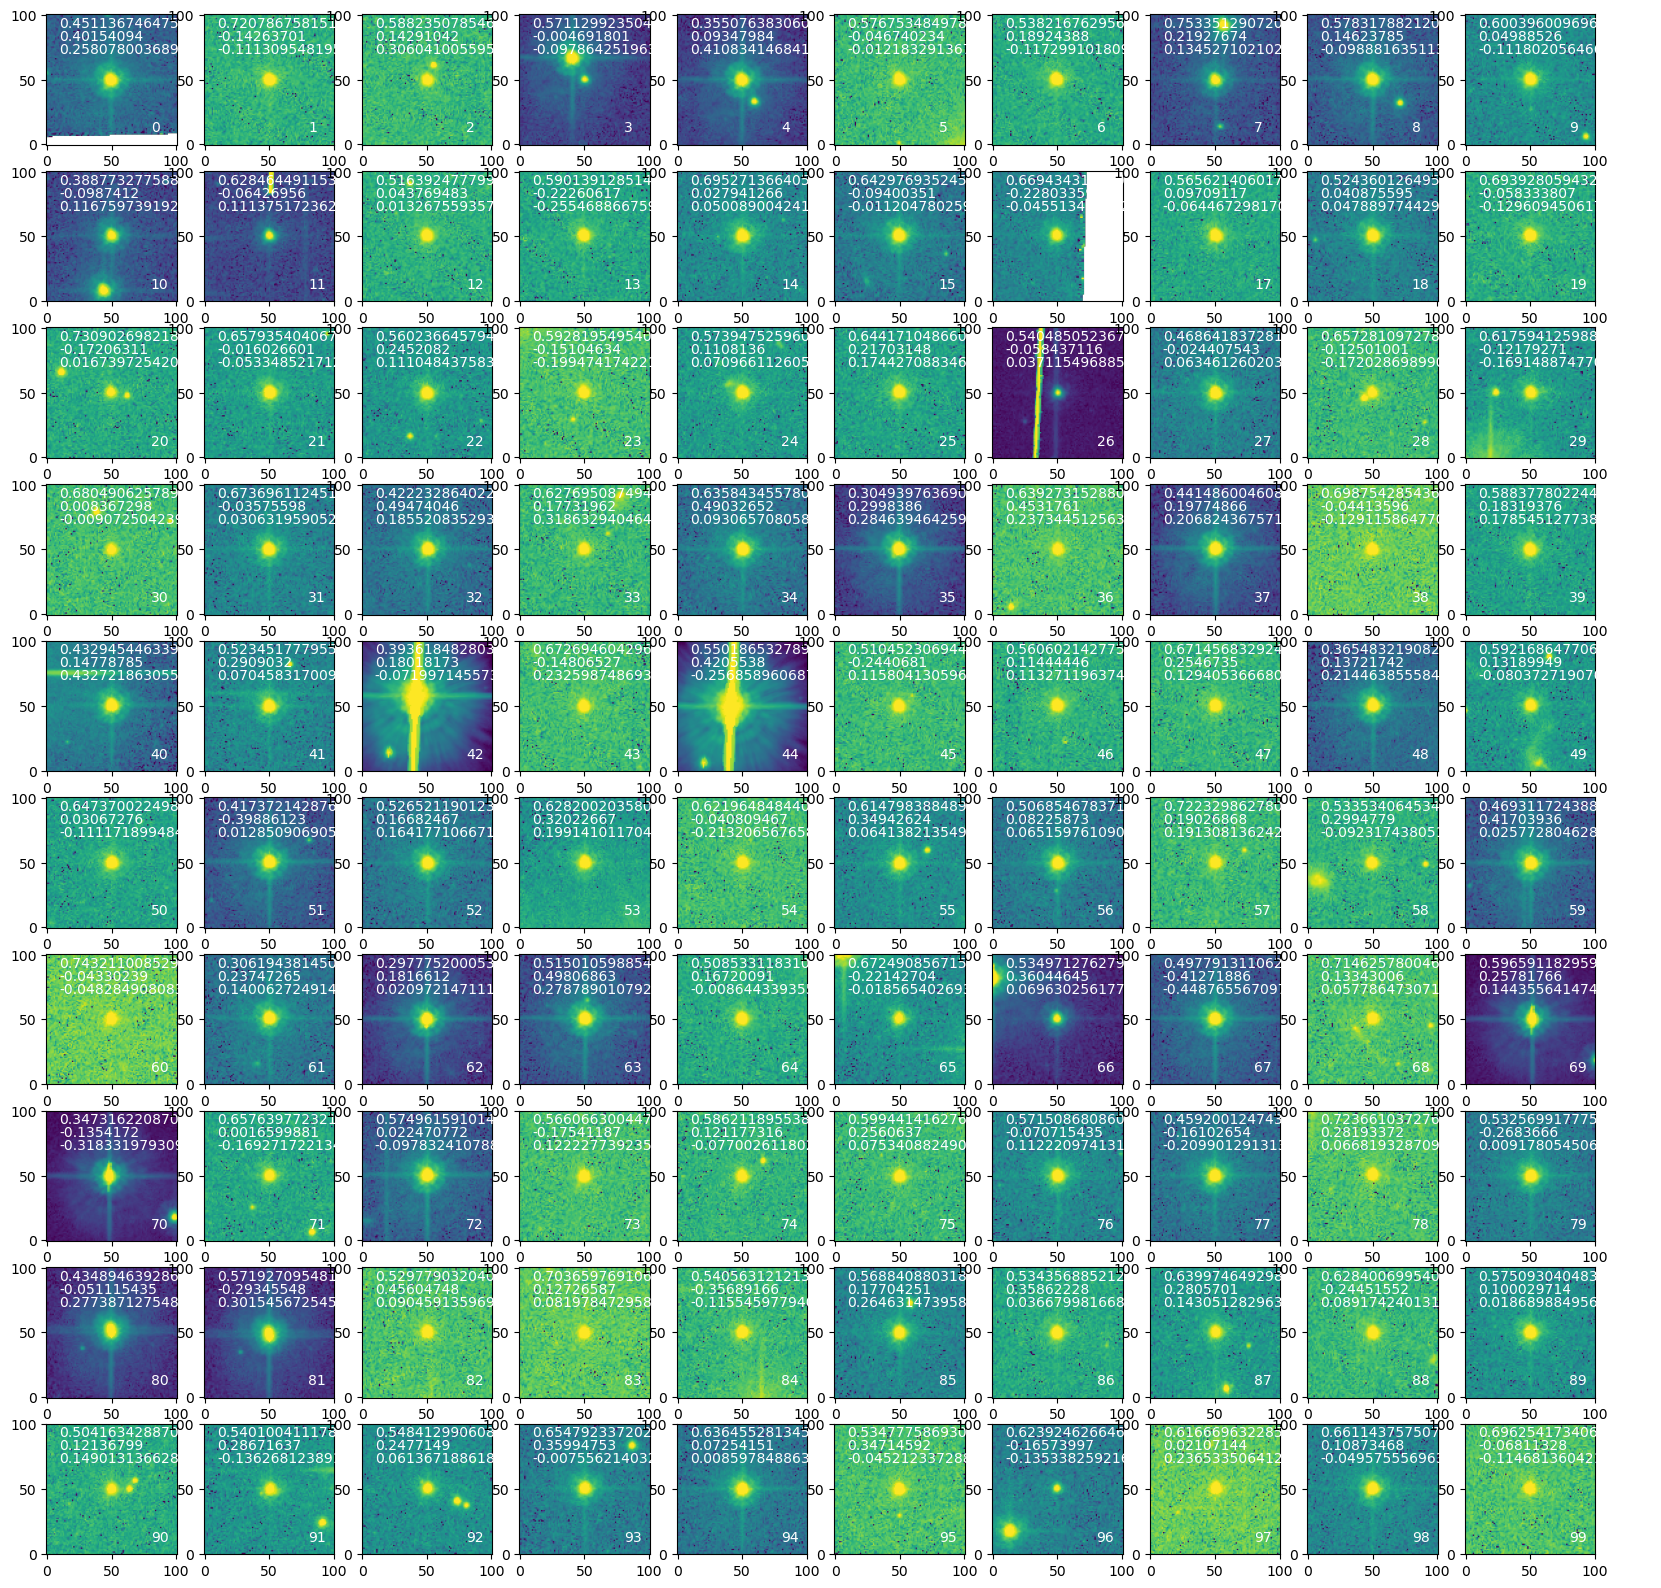

In [5]:
from photutils.detection import find_peaks
from astropy.table import Table
from astropy.stats import sigma_clipped_stats
from astropy.nddata import NDData
from photutils.psf import extract_stars
from astropy.visualization import simple_norm
from photutils.detection import DAOStarFinder

# PSFData
psf_image = '/users/aurora.mata/Documents/PJ170+20/j8rz01020_drz.fits'
hdul_psf = fits.open(psf_image)
# removing not used extensions
del hdul_psf[4]
del hdul_psf[3]
del hdul_psf[2]
hdul_psf.info()

# convert again to counts, just for consistency
hdul_psf[1].data = hdul_psf[1].data*hdul_psf[0].header['EXPTIME'] # convert from e-/s to e-
hdul_psf[1].header['EXPTIME'] = hdul_psf[0].header['EXPTIME']
hdul_psf[1].header['NCOMBINE'] = 1
hdul_psf[0].header['GAIN'] = hdul_psf[0].header['CCDGAIN']
hdul_psf[1].header['GAIN'] = hdul_psf[0].header['CCDGAIN']
hdul_psf[1].data = hdul_psf[1].data/hdul_psf[0].header['GAIN'] # convert from e- to ADU
hdul_psf[1].header['BUNIT']  = 'ADU'



# peaks_tbl = find_peaks(hdul_psf[1].data, threshold=10000.0)
# x = peaks_tbl['x_peak']  
# y = peaks_tbl['y_peak'] 

daofind = DAOStarFinder(fwhm=3.0, threshold=10000.0)
sources = daofind(hdul_psf[1].data - np.nanmedian(hdul_psf[1].data))
x = sources['xcentroid']  
y = sources['ycentroid']
peak = sources['peak']
sharp = sources['sharpness']
round1 = sources['roundness1']
round2 = sources['roundness2']

print(sources.columns)

# remove edges
size = 200 #200
central_buffer = 100
hsize = (size - 1) / 2
 
mask = ((x > hsize) & (x < (hdul_psf[1].data.shape[1] - 1 - hsize)) &
        (y > hsize) & (y < (hdul_psf[1].data.shape[0] - 1 - hsize)))
# avoid central gap
mask_y = (y < hdul_psf[1].data.shape[0]/2. - central_buffer) & (y < hdul_psf[1].data.shape[0]/2. + central_buffer)

# remove brightest sources
mask_peak = (peak < np.nanpercentile(peak, 90.))

# attempt to remove non round objects
mask_round = (np.abs(round1) < 0.5) & (np.abs(round2) < 0.5)
# remove less sharp sources
# mask_sharp = (sharp < np.nanpercentile(sharp, 90.))


stars_tbl = Table()
mask_final = mask&mask_y&mask_peak&mask_round
stars_tbl['x'] = x[mask_final]  
stars_tbl['y'] = y[mask_final]
stars_tbl['sharp'] = sharp[mask_final]
stars_tbl['round1'] = round1[mask_final]
stars_tbl['round2'] = round2[mask_final]
stars_tbl['idx'] = np.arange(len(stars_tbl))


print('\nTotal stars {}'.format(len(stars_tbl)))

mean_val, median_val, std_val = sigma_clipped_stats(hdul_psf[1].data, sigma=2.0)  
nddata = NDData(data=hdul_psf[1].data.copy() - median_val)
stars = extract_stars(nddata, stars_tbl, size=101) #Here

nrows = 10
ncols = int(np.round(len(stars_tbl)/nrows))
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 20),
                      squeeze=True)
ax = ax.ravel()
for i in range(nrows * ncols):
    norm = simple_norm(stars[i], 'log', percent=99.0)
    ax[i].imshow(stars[i], norm=norm, origin='lower', cmap='viridis')
    ax[i].text(0.1, 0.90, stars_tbl['sharp'][i], transform=ax[i].transAxes, c='white')
    ax[i].text(0.1, 0.80, stars_tbl['round1'][i], transform=ax[i].transAxes, c='white')
    ax[i].text(0.1, 0.70, stars_tbl['round2'][i], transform=ax[i].transAxes, c='white')
    ax[i].text(0.8, 0.10, stars_tbl['idx'][i], transform=ax[i].transAxes, c='white')

### Refine the selection of stars
Since the code takes a lot of stars that will not contribute to our PSF we eliminate manually the faint or not centered stars.


Total stars 84


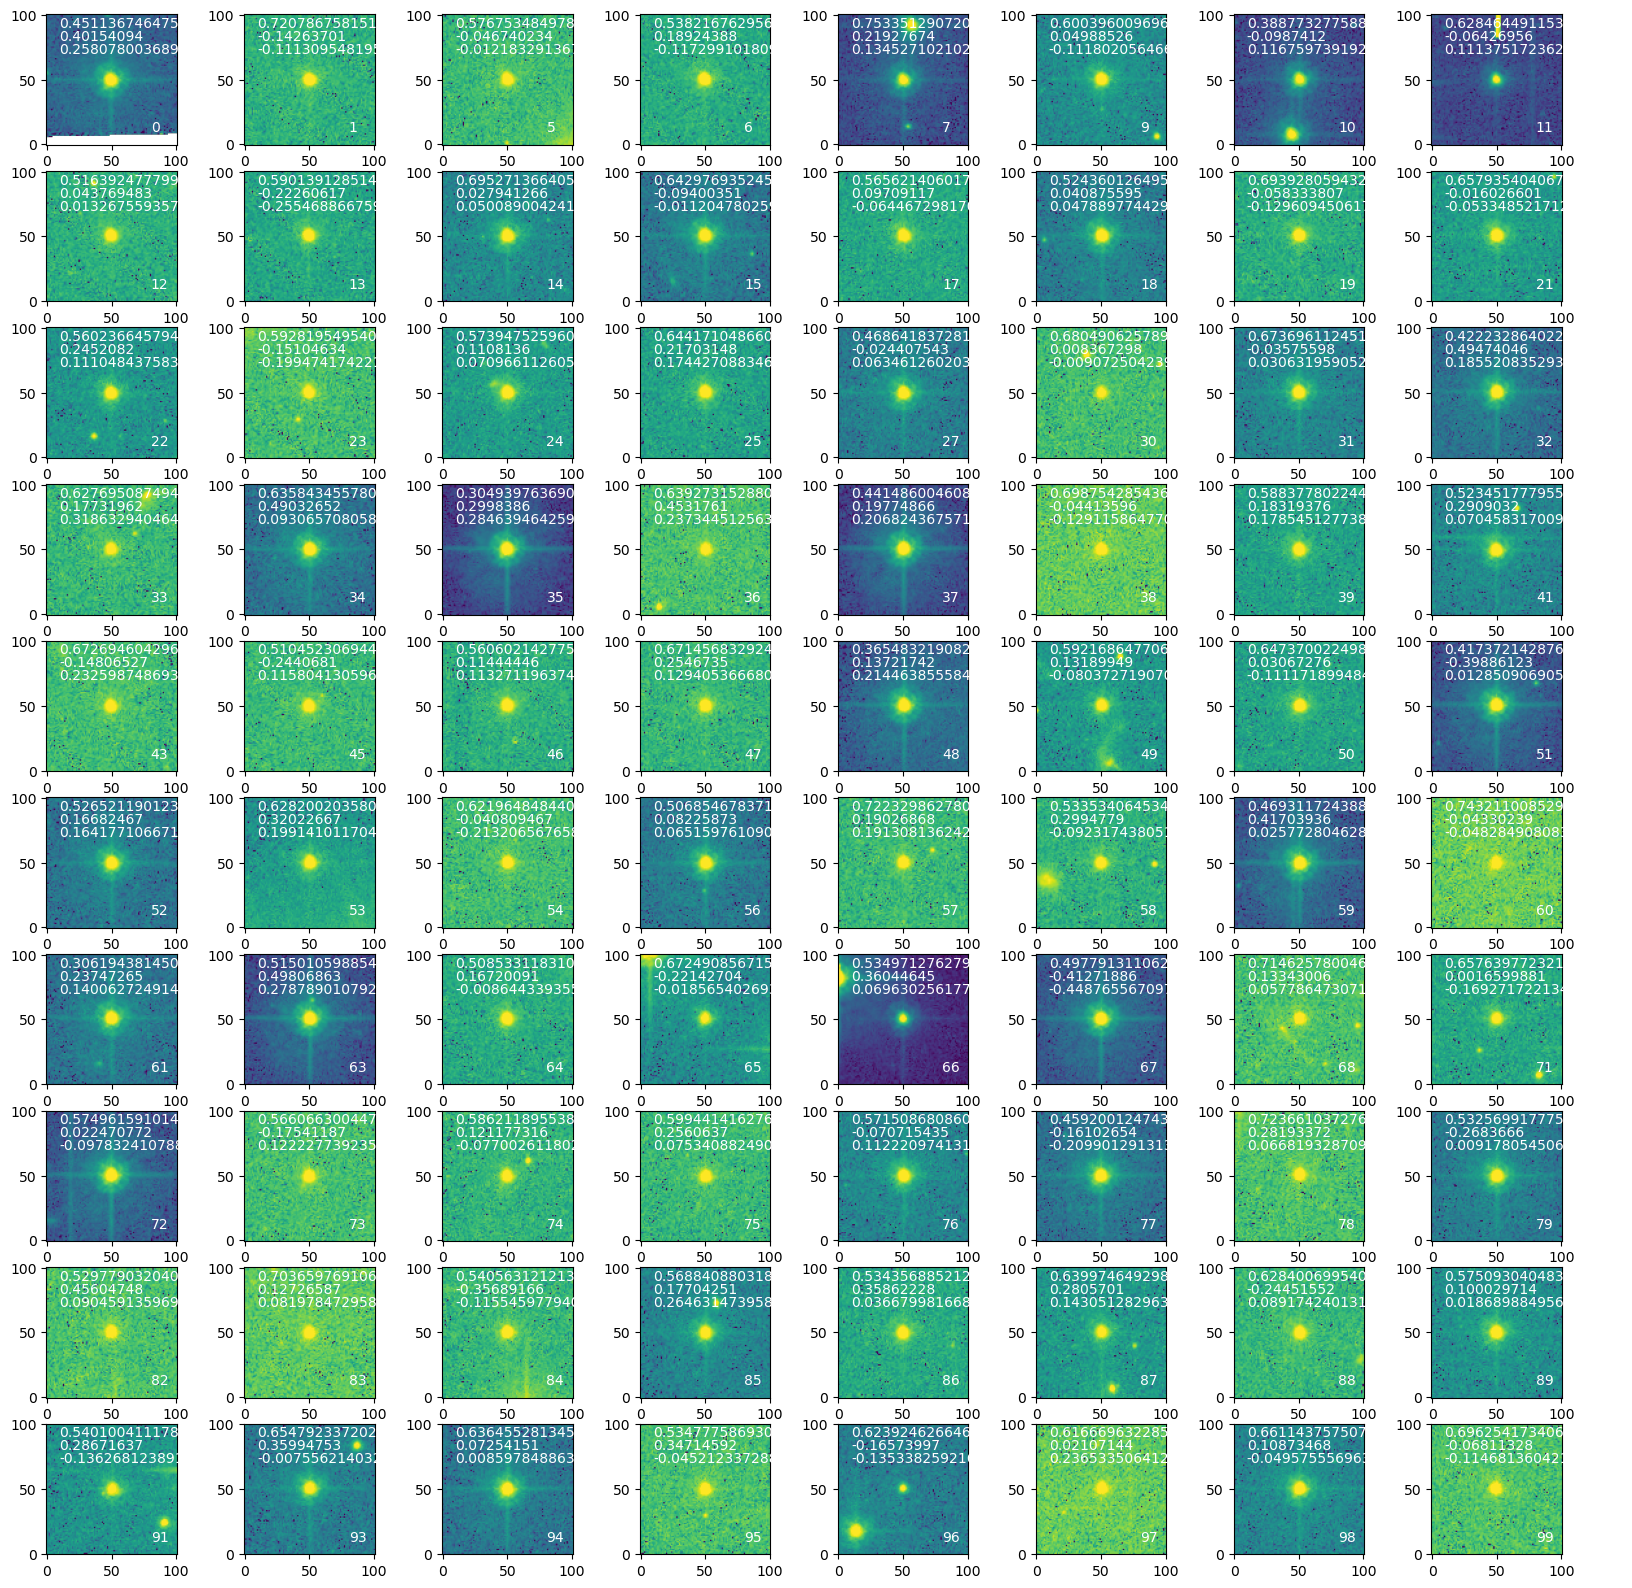

In [6]:
# visual cleaning
mask_idx = ( stars_tbl['idx'].data != 2 ) & ( stars_tbl['idx'].data != 3 ) & ( stars_tbl['idx'].data != 4 ) & \
           ( stars_tbl['idx'].data != 8 ) & ( stars_tbl['idx'].data != 16 ) & \
           ( stars_tbl['idx'].data != 20 ) & ( stars_tbl['idx'].data != 26 ) & ( stars_tbl['idx'].data != 28 ) & \
           ( stars_tbl['idx'].data != 42 ) & ( stars_tbl['idx'].data != 44 ) & ( stars_tbl['idx'].data != 62 ) & \
           ( stars_tbl['idx'].data != 69 ) & ( stars_tbl['idx'].data != 70 ) & ( stars_tbl['idx'].data != 80 ) & \
           ( stars_tbl['idx'].data != 81 )  & ( stars_tbl['idx'].data != 90 ) & ( stars_tbl['idx'].data != 92 ) & \
           ( stars_tbl['idx'].data != 29 )  & ( stars_tbl['idx'].data != 40 ) & ( stars_tbl['idx'].data != 55 )

stars_tbl = stars_tbl[mask_idx]

print('\nTotal stars {}'.format(len(stars_tbl)))


stars = extract_stars(nddata, stars_tbl, size=101)


nrows = 10
ncols = int(np.round(len(stars_tbl)/nrows))
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 20),
                      squeeze=True)
ax = ax.ravel()
for i in range(nrows * ncols):
    norm = simple_norm(stars[i], 'log', percent=99.0)
    ax[i].imshow(stars[i], norm=norm, origin='lower', cmap='viridis')
    ax[i].text(0.1, 0.90, stars_tbl['sharp'][i], transform=ax[i].transAxes, c='white')
    ax[i].text(0.1, 0.80, stars_tbl['round1'][i], transform=ax[i].transAxes, c='white')
    ax[i].text(0.1, 0.70, stars_tbl['round2'][i], transform=ax[i].transAxes, c='white')
    ax[i].text(0.8, 0.10, stars_tbl['idx'][i], transform=ax[i].transAxes, c='white')

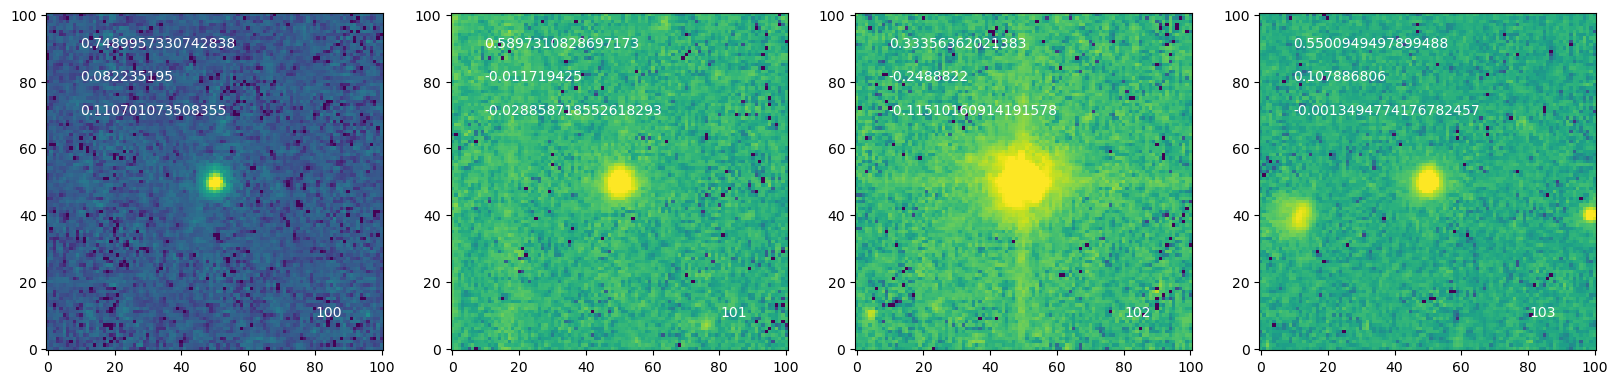

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=len(stars_tbl)-(nrows * ncols), figsize=(20, 20),
                      squeeze=True)
ax = ax.ravel()
for i in range(len(stars_tbl)-(nrows * ncols)):
    norm = simple_norm(stars[i], 'log', percent=99.0)
    ax[i].imshow(stars[i+(nrows * ncols)], norm=norm, origin='lower', cmap='viridis')
    ax[i].text(0.1, 0.90, stars_tbl['sharp'][i+(nrows * ncols)], transform=ax[i].transAxes, c='white')
    ax[i].text(0.1, 0.80, stars_tbl['round1'][i+(nrows * ncols)], transform=ax[i].transAxes, c='white')
    ax[i].text(0.1, 0.70, stars_tbl['round2'][i+(nrows * ncols)], transform=ax[i].transAxes, c='white')
    ax[i].text(0.8, 0.10, stars_tbl['idx'][i+(nrows * ncols)], transform=ax[i].transAxes, c='white')

## Section 3: Construction of PSF
We finally build and write our PSF as a fits object. This fits file will be used in the analysis of GALFIT to substract the contribution and search for foreground objects.

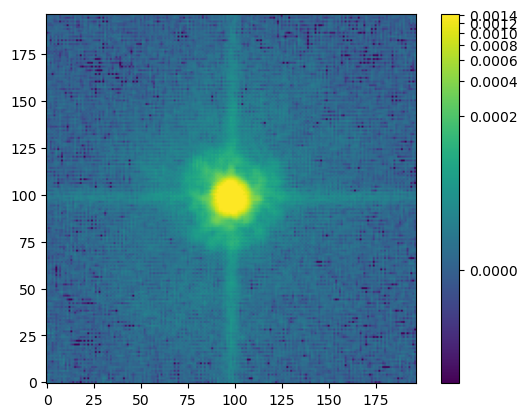

In [8]:
from photutils.psf import EPSFBuilder
epsf_builder = EPSFBuilder(oversampling=2, maxiters=5,
                           progress_bar=False)  
epsf, fitted_stars = epsf_builder(stars)  
import matplotlib.pyplot as plt

norm = simple_norm(epsf.data[3:-3,3:-3], 'log', percent=99.0)
plt.imshow(epsf.data[3:-3,3:-3], norm=norm, origin='lower', cmap='viridis')
plt.colorbar()

hdu = fits.PrimaryHDU(data=epsf.data[3:-3,3:-3])
hdul = fits.HDUList([hdu])
#hdul.writeto('PSF.fits', overwrite=True) #Save PSF